In [99]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
from sklearn.preprocessing import PowerTransformer, StandardScaler

**Get Data from sources : Data warehouse**

In [6]:
rice_data = pd.read_csv("./data/data_warehouse/mdg_rice_data.csv")

In [7]:
rice_data["date"] = pd.to_datetime(rice_data["date"])

**Overview of the data**

In [8]:
rice_data.describe()

,date,market_id,latitude,longitude,commodity_id,price,usdprice,gasoline_price,diesel_price,kerosene_price,Phosphate rock,DAP,TSP,Urea,Potassium chloride
count,3357,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000
mean,2022-07-22 05:21:17.211796224,5465.691391,-23.326381,45.681308,68.020256,2719.932779,0.649053,5182.970807,4314.624665,2356.650581,205.743899,570.015903,502.204242,410.573871,446.281972
min,2015-12-15 00:00:00,732.000000,-25.530000,43.620000,64.000000,665.000000,0.210000,3640.000000,3000.000000,2130.000000,70.750000,263.000000,240.000000,186.250000,206.500000
25%,2021-09-15 00:00:00,4617.000000,-24.480000,44.670000,64.000000,2450.000000,0.600000,4100.000000,3400.000000,2130.000000,147.500000,522.000000,447.500000,313.500000,292.500000
50%,2023-02-15 00:00:00,6567.000000,-23.900000,45.440000,71.000000,2800.000000,0.650000,5900.000000,4900.000000,2430.000000,152.500000,568.330000,478.000000,352.000000,331.880000
75%,2024-01-15 00:00:00,7199.000000,-23.290000,46.380000,71.000000,3150.000000,0.710000,5900.000000,4900.000000,2430.000000,320.000000,625.000000,555.000000,436.500000,508.750000
max,2025-03-15 00:00:00,11282.000000,-12.280000,50.170000,71.000000,3850.000000,0.920000,5900.000000,4970.000000,2830.000000,347.500000,954.000000,856.000000,925.000000,1202.000000
std,NaN,2966.248261,2.088586,1.394623,3.461633,561.773653,0.096432,899.903651,747.311161,149.333070,96.571988,141.108767,135.335625,173.985636,255.583771


**View Data distribution**

<Axes: xlabel='price', ylabel='Count'>

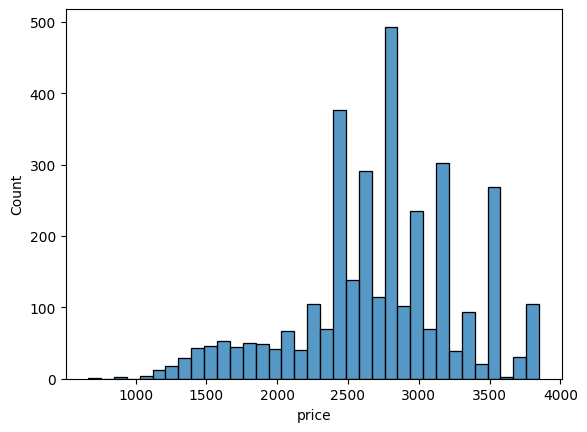

In [9]:
sns.histplot(rice_data["price"])

In [10]:
rice_data["price"].skew()

np.float64(-0.4312204653638156)

**Interpretations**
- The data description with `rice_data.describe()` shows that :  **mean("price") < mediane("price")**
- The histogram shows that the majority of the data is located on the right side of the histogram
- The value of the skewness is < -0.3

--> So the distribution of the rice price (the target) is left-skewed.
**So what ?** => Transformation needed for a more reliable model.

**Applied transformation**
- The transformation applied to the rice price data are:
    - **Box-Cox Transformation**
    - **Standardization (mean = 0, std-deviation = 1)**

In [11]:
pt = PowerTransformer(method="box-cox", standardize=True)
price_reshaped = rice_data["price"].to_numpy().reshape(-1, 1)
rice_data['price_transformed'] = pt.fit_transform(price_reshaped)

**Box-cox transfo compared with Normal distribution**

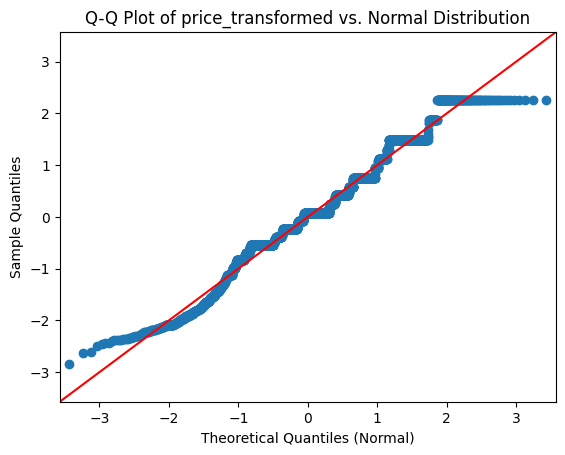

In [12]:
sm.qqplot(rice_data["price_transformed"], line='45', fit=True)

plt.title('Q-Q Plot of price_transformed vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles (Normal)')
plt.ylabel('Sample Quantiles')
plt.show()

**Square Transformation**

In [13]:
rice_data["price_squared"] = (rice_data["price"].to_numpy())**3

**Square Transformation compared with Normal distro**

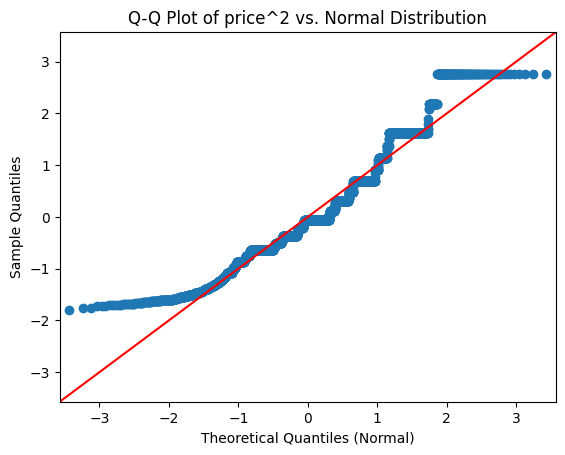

In [14]:
sm.qqplot(rice_data["price_squared"], line='45', fit=True)

plt.title('Q-Q Plot of price^2 vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles (Normal)')
plt.ylabel('Sample Quantiles')
plt.show()

**Reflexion method**

In [15]:
K = rice_data["price"].max() + 1
rice_data["price_reflected"] = np.sqrt(K - rice_data["price"].to_numpy())

<Axes: xlabel='price_reflected', ylabel='Count'>

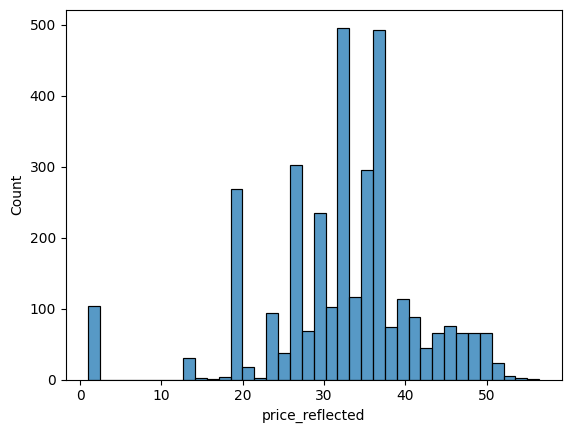

In [16]:
sns.histplot(rice_data["price_reflected"])

**Normalization**

In [17]:
scaler = StandardScaler()

rice_data['price_reflected'] = scaler.fit_transform(rice_data[['price_reflected']])

**Reflexion method compared with Normal distro**

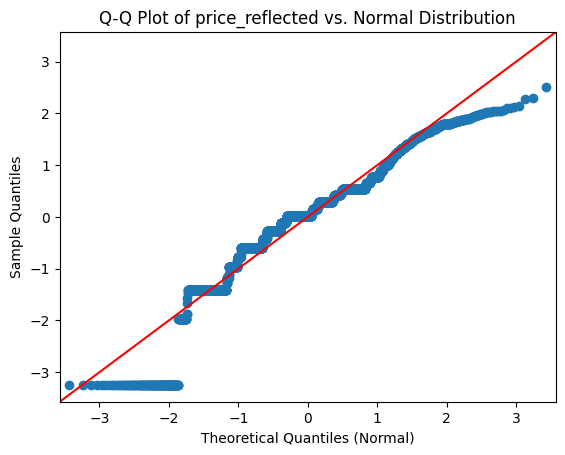

In [18]:
sm.qqplot(rice_data["price_reflected"], line='45', fit=True)

plt.title('Q-Q Plot of price_reflected vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles (Normal)')
plt.ylabel('Sample Quantiles')
plt.show()

**Skewness comparison**

In [19]:
print(rice_data["price_transformed"].skew()) # box-cox
print(rice_data["price_squared"].skew())
print(rice_data["price_reflected"].skew())

-0.02508180312040639
0.7363905695585387
-0.8824423282772889


The skewness of the feature "price_transformed" (**box-cox transformation**) is acceptable.

The **exchange rate between USD and MGA** can be correlated with the rice price in Madagascar.

In [22]:
usd_mga_exchange = yf.download("USDMGA=X", start="2015-01-01", end="2026-03-24")

[*********************100%***********************]  1 of 1 completed


- Why do I use the feature "Close" ?
    - Because : it reflects the actual value used for accounting balance sheets and portfolio valuations.
- Why do I use the mean of the feature "Close" ?
    - Because : The mean is representative of the general trend of the month.

In [23]:
currency_data = usd_mga_exchange.resample("MS").mean()["Close"]
currency_data = currency_data.reset_index()
currency_data.columns = [col.lower() for col in currency_data.columns]
currency_data["date"] = pd.to_datetime(currency_data["date"])
currency_data["usdmga"] = currency_data["usdmga=x"]

Here, I add the monthly currency exchange to the rice data.

In [24]:
rice_data = pd.merge_asof(
            rice_data.sort_values('date'), 
            currency_data.sort_values('date')[['date','usdmga']],
            on='date', 
            direction='backward'
        )

In [25]:
# exclude other form of the column "price" to avoid data leakage
non_price_columns = [col for col in rice_data.columns if not col.startswith('price') and not col.startswith('usdprice')]

Here, I compute the correlation between the **pre-selected** columns and the **target** to have a list of the applicants features.

In [ ]:
corr_price = rice_data[non_price_columns].corrwith(rice_data["price_transformed"], numeric_only=True).sort_values()

<Axes: >

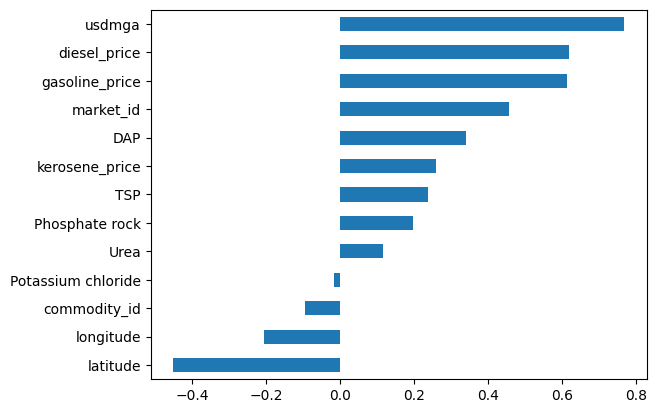

In [27]:
corr_price.plot(kind="barh")

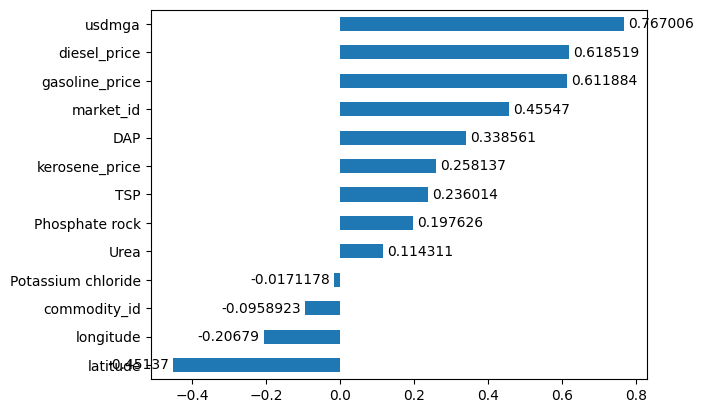

In [28]:
ax = corr_price.plot(kind="barh")
ax.bar_label(ax.containers[0], padding=3)
plt.show()

I exclude the features whose the absolute value of the correlation with the target is less than 0,3.

**Why ?**
- less column to manage
- less computation power needed
- prevent overfitting

In [29]:
applicants_feats = [key for key in corr_price.keys() if abs(corr_price[key]) > 0.3]
applicants_feats

['latitude', 'DAP', 'market_id', 'gasoline_price', 'diesel_price', 'usdmga']

Now I compute the correlation between the applicant features, because, a hight correlation between two features means multicollinearty (Maybe, they talk about the same thing, or there is linear dependency between them).

In [38]:
corr_inter_features = rice_data[applicants_feats].corr()

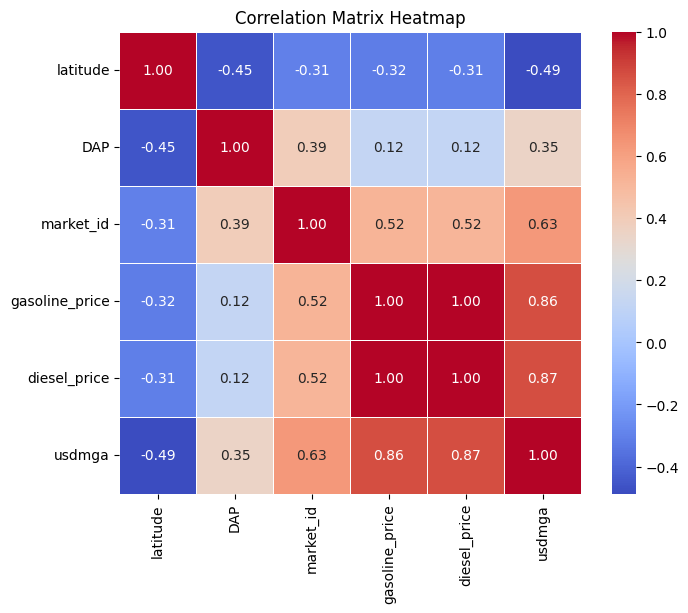

In [39]:
# 3. Plot the heatmap
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(
    corr_inter_features,
    annot=True,      # Annotate each cell with the correlation value
    cmap='coolwarm', # Choose a color palette (cool for negative, warm for positive)
    fmt=".2f",       # Format the annotations to two decimal places
    linewidths=.5,   # Add lines between cells
    square=True      # Ensure cells are square
)
plt.title('Correlation Matrix Heatmap')
plt.show()

The graph shows that some features are hightly correlated: if two variable are correlated, I only keep one of them to avoid multicollinearity.

In [41]:
corr_inter_features = corr_inter_features.stack().to_dict()

In [42]:
corr_inter_features.keys()

dict_keys([('latitude', 'latitude'), ('latitude', 'DAP'), ('latitude', 'market_id'), ('latitude', 'gasoline_price'), ('latitude', 'diesel_price'), ('latitude', 'usdmga'), ('DAP', 'latitude'), ('DAP', 'DAP'), ('DAP', 'market_id'), ('DAP', 'gasoline_price'), ('DAP', 'diesel_price'), ('DAP', 'usdmga'), ('market_id', 'latitude'), ('market_id', 'DAP'), ('market_id', 'market_id'), ('market_id', 'gasoline_price'), ('market_id', 'diesel_price'), ('market_id', 'usdmga'), ('gasoline_price', 'latitude'), ('gasoline_price', 'DAP'), ('gasoline_price', 'market_id'), ('gasoline_price', 'gasoline_price'), ('gasoline_price', 'diesel_price'), ('gasoline_price', 'usdmga'), ('diesel_price', 'latitude'), ('diesel_price', 'DAP'), ('diesel_price', 'market_id'), ('diesel_price', 'gasoline_price'), ('diesel_price', 'diesel_price'), ('diesel_price', 'usdmga'), ('usdmga', 'latitude'), ('usdmga', 'DAP'), ('usdmga', 'market_id'), ('usdmga', 'gasoline_price'), ('usdmga', 'diesel_price'), ('usdmga', 'usdmga')])

In [78]:
correlated_applicants_feats = np.array(sorted([sorted(key) for key in corr_inter_features.keys() if abs(corr_inter_features[key]) > 0.85]))
applicants_feats_copy = applicants_feats.copy()
for ccf in correlated_applicants_feats:
    if str(ccf[0]) != str(ccf[1]):
        substitute = str(ccf[0]) if abs(corr_price[ccf[0]]) > abs(corr_price[ccf[1]]) else str(ccf[1])
        element_1 = applicants_feats_copy.index(ccf[0]) if ccf[0] in applicants_feats_copy else -1
        element_2 = applicants_feats_copy.index(ccf[1]) if ccf[1] in applicants_feats_copy else -1
        if element_1 != -1:
            applicants_feats_copy[element_1] = substitute
        if element_2 != -1:
            applicants_feats_copy[element_2] = substitute
candidates_feats = list(set(applicants_feats_copy))

In [79]:
candidates_feats = {float(corr_price[cand]): cand for cand in candidates_feats}

In [87]:
candidates_feats = [candidates_feats[key] for key in sorted(candidates_feats.keys())[::-1]]

Here are the candidate features (sorted by the value of the correlation between the feature and the target.)

In [88]:
candidates_feats

['usdmga', 'market_id', 'DAP', 'latitude']